In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [ ]:
INPUT_DIM = 2
COUPLING_DIM = 256
COUPLING_LAYERS = 4
BATCH_SIZE = 256
LR = 1e-4
EPOCHS = 300

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [ ]:
class MoonsDataset(Dataset):
    def __init__(self, n_samples=30000, noise=0.05):
        data, _ = make_moons(n_samples=n_samples, noise=noise)
        self.data = ((data - data.mean(0)) / data.std(0)).astype(np.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

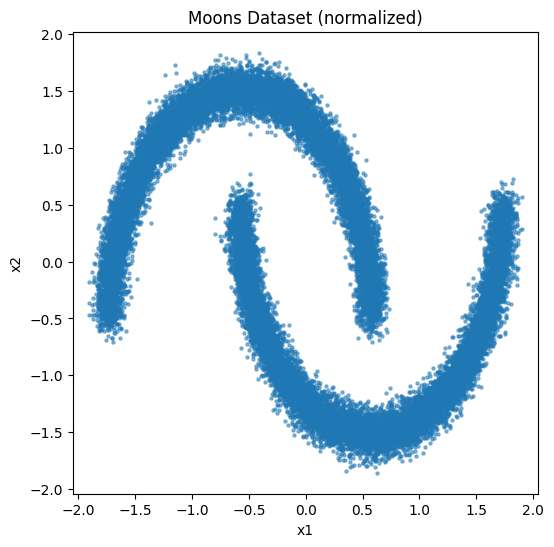

In [ ]:
dataset_vis = MoonsDataset()
data_vis = dataset_vis.data

plt.figure(figsize=(6, 6))
plt.scatter(data_vis[:, 0], data_vis[:, 1], s=5, alpha=0.5)
plt.title("Moons Dataset (normalized)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.show()

In [ ]:
class CouplingLayer(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()

        self.scale_net = nn.Sequential(
            nn.Linear(input_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim // 2),
            nn.Tanh()
        )

        self.translate_net = nn.Sequential(
            nn.Linear(input_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim // 2)
        )

    def forward(self, x, mask, reverse=False):
        x_a = x * mask
        x_b = x * (1 - mask)

        x_a_cond = x_a[:, mask.bool()]

        s = self.scale_net(x_a_cond)
        t = self.translate_net(x_a_cond)

        if not reverse:
            y_b = x_b[:, (1 - mask).bool()] * torch.exp(s) + t
            log_det_jac = s.sum(dim=1)
        else:
            y_b = (x_b[:, (1 - mask).bool()] - t) * torch.exp(-s)
            log_det_jac = -s.sum(dim=1)

        y = torch.zeros_like(x)
        y[:, mask.bool()] = x_a_cond
        y[:, (1 - mask).bool()] = y_b

        return y, log_det_jac

In [ ]:
class RealNVP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_flows):
        super().__init__()

        self.prior = torch.distributions.MultivariateNormal(
            torch.zeros(input_dim).to(DEVICE),
            torch.eye(input_dim).to(DEVICE)
        )

        self.layers = nn.ModuleList(
            [CouplingLayer(input_dim, hidden_dim) for _ in range(num_flows)]
        )

        self.masks = [
            torch.tensor([i % 2, (i + 1) % 2]).float().to(DEVICE)
            for i in range(num_flows)
        ]

    def forward(self, x):
        log_det_J = 0
        for layer, mask in zip(self.layers, self.masks):
            x, log_det = layer(x, mask, reverse=False)
            log_det_J += log_det
        return x, log_det_J

    def loss(self, x):
        z, log_det_J = self(x)
        log_prob = self.prior.log_prob(z)
        return -(log_det_J + log_prob).mean()

    def sample(self, num_samples):
        z = self.prior.sample((num_samples,))
        for layer, mask in reversed(list(zip(self.layers, self.masks))):
            z, _ = layer(z, mask, reverse=True)
        return z

In [ ]:
dataset = MoonsDataset()
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

model = RealNVP(INPUT_DIM, COUPLING_DIM, COUPLING_LAYERS).to(DEVICE)

print(model)

RealNVP(
  (layers): ModuleList(
    (0-3): 4 x CouplingLayer(
      (scale_net): Sequential(
        (0): Linear(in_features=1, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=256, bias=True)
        (3): ReLU()
        (4): Linear(in_features=256, out_features=1, bias=True)
        (5): Tanh()
      )
      (translate_net): Sequential(
        (0): Linear(in_features=1, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=256, bias=True)
        (3): ReLU()
        (4): Linear(in_features=256, out_features=1, bias=True)
      )
    )
  )
)


In [ ]:
def train(model, loader, epochs, lr):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        tqdm_loader = tqdm(loader, desc=f"Training RealNVP - Epoch {epoch+1}/{epochs}")

        for batch in tqdm_loader:
            batch = batch.to(DEVICE)

            optimizer.zero_grad()
            loss = model.loss(batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            tqdm_loader.set_postfix(loss=loss.item())

        epoch_loss = total_loss / len(loader)
        losses.append(epoch_loss)
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {epoch_loss:.6f}")

    return losses

In [ ]:
losses = train(model, loader, EPOCHS, LR)

Training RealNVP - Epoch 1/300:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch [1/300], Train Loss: 2.412019


Training RealNVP - Epoch 2/300:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch [2/300], Train Loss: 2.018841


Training RealNVP - Epoch 3/300:   0%|          | 0/118 [00:00<?, ?it/s]

...

Epoch [298/300], Train Loss: 1.214397


Training RealNVP - Epoch 299/300:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch [299/300], Train Loss: 1.220284


Training RealNVP - Epoch 300/300:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch [300/300], Train Loss: 1.213212


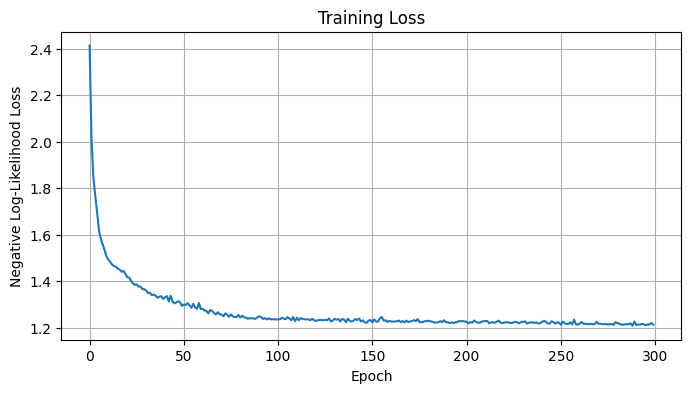

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood Loss")
plt.grid(True)
plt.show()

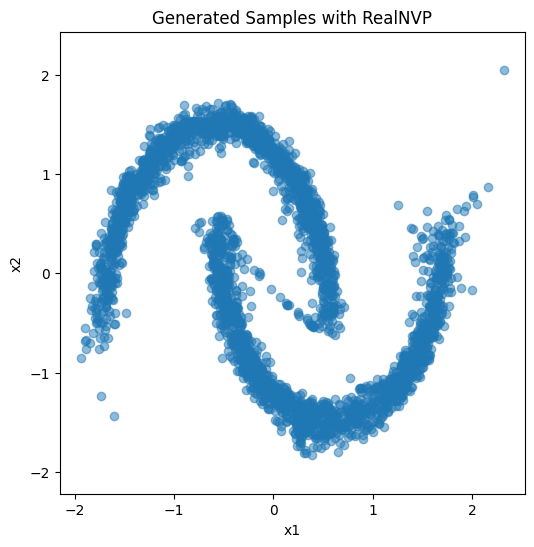

In [ ]:
samples = model.sample(3000).cpu().detach().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
plt.title("Generated Samples with RealNVP")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.show()

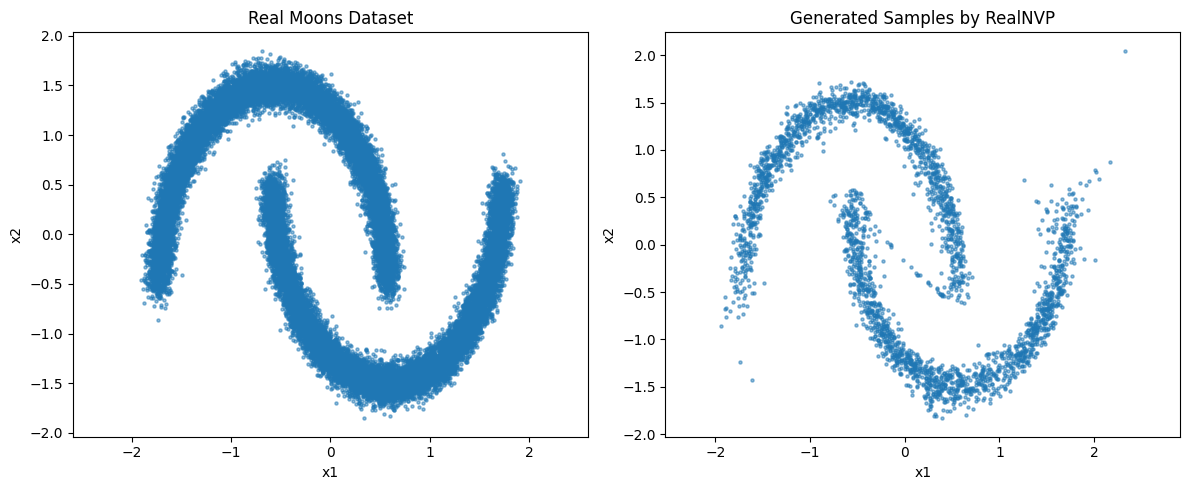

In [ ]:
real_data = dataset.data

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(real_data[:, 0], real_data[:, 1], s=5, alpha=0.5)
plt.title("Real Moons Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")

plt.subplot(1, 2, 2)
plt.scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.5)
plt.title("Generated Samples by RealNVP")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")

plt.tight_layout()
plt.show()

In [ ]:
batch = next(iter(loader)).to(DEVICE)
z, log_det = model(batch)

print("Input batch shape :", batch.shape)
print("Latent z shape    :", z.shape)
print("Log det shape     :", log_det.shape)
print("Exemple log_det   :", log_det[:5])

Input batch shape : torch.Size([256, 2])
Latent z shape    : torch.Size([256, 2])
Log det shape     : torch.Size([256])
Exemple log_det   : tensor([1.3356, 2.2983, 1.6915, 1.4190, 1.3491], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [ ]:
torch.save(model.state_dict(), "realnvp_moons.pth")
print("Modèle sauvegardé dans realnvp_moons.pth")

Modèle sauvegardé dans realnvp_moons.pth


In [ ]:
model.load_state_dict(torch.load("realnvp_moons.pth", map_location=DEVICE))
model.eval()
print("Modèle rechargé")

Modèle rechargé


In [ ]:
from IPython.display import Markdown, display

display(Markdown(r"""
### RealNVP — idée générale

Les Normalizing Flows transforment une distribution simple, souvent une gaussienne, en une distribution complexe grâce à une suite de transformations inversibles.

Dans RealNVP, chaque couche de couplage garde une partie de l'entrée inchangée et transforme l'autre partie avec deux réseaux :
- un réseau d'échelle \( s(\cdot) \)
- un réseau de translation \( t(\cdot) \)

Cela permet :
- une transformation inversible
- un calcul efficace du déterminant du Jacobien
- une estimation exacte de la log-vraisemblance

Le modèle apprend en maximisant la vraisemblance des données, ou de manière équivalente en minimisant la negative log-likelihood.
"""))


### RealNVP — idée générale

Les Normalizing Flows transforment une distribution simple, souvent une gaussienne, en une distribution complexe grâce à une suite de transformations inversibles.

Dans RealNVP, chaque couche de couplage garde une partie de l'entrée inchangée et transforme l'autre partie avec deux réseaux :
- un réseau d'échelle \( s(\cdot) \)
- un réseau de translation \( t(\cdot) \)

Cela permet :
- une transformation inversible
- un calcul efficace du déterminant du Jacobien
- une estimation exacte de la log-vraisemblance

Le modèle apprend en maximisant la vraisemblance des données, ou de manière équivalente en minimisant la negative log-likelihood.
